In [1]:
import sys

import os
sys.path.append(os.path.abspath('../'))

In [2]:
from src.algorithms.ESN_GA import ESN_GA
from src.algorithms.ESN_BO import ESN_BO
from src.utils import runModel
import reservoirpy
reservoirpy.verbosity(0)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle

def readSavedExperiment(path):
    file = open(path, "rb")
    return pickle.load(file)

def get_preds(directory, dataset, isAutoregressive):
    best_preds = None
    target = None
    best_nrmse = np.inf
    for i in range(5):
        ga: ESN_GA | ESN_BO = readSavedExperiment("{}/{}/backup_{}.obj".format(directory, dataset, i))

        best_model = ga.bestModel
        if isAutoregressive:
            runModel(best_model, ga.experimentData.trainX)
            prevOutput = ga.experimentData.valX[0]
            preds = []
            for _ in range(len(ga.experimentData.valX)):
                pred = runModel(best_model, prevOutput)
                prevOutput = pred
                preds.append(pred[0])
            preds = np.array(preds)
            nrmse_error = ga.evalParams.errorMetrics[0](ga.experimentData.valY, preds)
            if nrmse_error < best_nrmse:
                best_nrmse = nrmse_error
                best_preds = preds
                target = ga.experimentData.valY
        else:
            runModel(best_model, ga.experimentData.valX)
            preds = runModel(best_model, ga.experimentData.testX)
            nrmse_error = ga.evalParams.errorMetrics[0](ga.experimentData.testY, preds)
            if nrmse_error < best_nrmse:
                best_nrmse = nrmse_error
                best_preds = preds
                target = ga.experimentData.testY
    return best_preds, target


def plot(dataset, title, is_autoregressive=True):
    ga_preds, ga_target = get_preds(f'../results/ga', dataset, is_autoregressive)
    bo_preds, bo_target = get_preds(f'../results/bo', dataset, is_autoregressive)
    esnas_preds, esnas_target = get_preds(f'../results/esnas', dataset, is_autoregressive)
    # Check if all targets are the same
    ga_target_equal = (ga_target == bo_target).all()
    bo_target_equal = (bo_target == esnas_target).all()
    ga_target_equal = (ga_target == esnas_target).all()
    assert ga_target_equal and bo_target_equal and ga_target_equal, "Targets are not the same"
    
    plt.figure(figsize=(16, 4))
    plt.plot(esnas_target[:25], color='blue')
    plt.plot(ga_preds[:25], color='red')
    plt.plot(bo_preds[:25], color='orange')
    plt.plot(esnas_preds[:25], color='green')
    plt.xlabel("Timestamp")
    plt.title(title)
    plt.legend(['Target', 'GA', 'BO', 'ESNAS'], loc='upper right')
    plt.show()


In [ ]:
plot('mgs', 'MGS')
plot('lorenz', 'Lorenz')
plot('laser', 'Santa fe laser')
plot('dde', 'DDE')
plot('sunspots', 'Sunspots', False)
plot('water', 'Water', False)

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_esn_architecture(architecture):
    lastNode = len(architecture['nodes']) - 1
    architecture['nodes'].append({'type': 'Output'})
    architecture['edges'].append([lastNode, lastNode+1])
    G = nx.DiGraph()
    
    # Add nodes
    for i, node in enumerate(architecture['nodes']):
        G.add_node(i, **node)
    
    G.add_edges_from(architecture['edges'])
    
    # Compute node levels (x-coordinates)
    levels = {}
    def dfs(node, level):
        if node not in levels:
            levels[node] = level
            for neighbor in G.neighbors(node):
                dfs(neighbor, level + 1)
    
    # Start DFS from input nodes (nodes with in_degree 0)
    input_nodes = [node for node in G.nodes() if G.in_degree(node) == 0]
    for input_node in input_nodes:
        dfs(input_node, 0)
    
    # Compute node positions
    pos = {}
    level_counts = {}
    for node, level in levels.items():
        if level not in level_counts:
            level_counts[level] = 0
        y = level_counts[level]
        level_counts[level] += 1
        pos[node] = (level, -y)  # Negative y to have top-to-bottom layout
    
    # Set up the plot
    plt.figure(figsize=(12, 8))
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
    
    # Draw edges with arrows
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                           arrowsize=20, arrowstyle='wedge', connectionstyle='arc3,rad=0')
    
    # Add labels (only node type)
    labels = {i: data['type'] for i, data in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight="bold")
    
    # Set title and remove axis
    plt.title("Echo State Network Architecture", fontsize=16)
    plt.axis('off')
    
    # Show the plot
    plt.tight_layout()
    plt.show()

In [2]:
import numpy as np

def findBestGaArchitecture(ga: ESN_GA):
    errors = [errors[0] for errors in ga.fitnesses]
    gaBestError = min(errors)
    gaBestErrorIndex = errors.index(gaBestError)
    gaBestModel = ga.architectures[gaBestErrorIndex]
    return gaBestModel, gaBestError

def findBestGasArchitecture(gas: list[ESN_GA]):
    bestError = np.inf
    bestArchitecture = None
    for ga in gas:
        architecture, error = findBestGaArchitecture(ga)
        if error<bestError:
            bestArchitecture = architecture
    return bestArchitecture


NameError: name 'ESN_GA' is not defined

In [ ]:
import matplotlib.pyplot as plt
from src.algorithms.ESN_GA import ESN_GA
import pickle

def plotConvergences(dataset, title, max_y_axis=3, min_y_axis=0):
    esnas_gas : list[ESN_GA] = [pickle.load(open(f'../results/esnas/{dataset}/backup_{i}.obj', 'rb')) for i in range(5)]
    gas: list[ESN_GA] = [pickle.load(open(f'../results/ga/{dataset}/backup_{i}.obj', 'rb')) for i in range(5)]
    bos: list[ESN_BO] = [pickle.load(open(f'../results/bo/{dataset}/backup_{i}.obj', 'rb')) for i in range(5)]

    esnas_best_until = []
    ga_best_until = []
    bo_best_until = []
    for i in range(5):
        esnas_ga = esnas_gas[i]
        ga = gas[i]
        bo = bos[i]
        esnas_nrmse = [error[0] for error in esnas_ga.fitnesses]
        ga_nrmse = [error[0] for error in ga.fitnesses]
        bo_nrmse = [error[0] for error in bo.performances]

        esnas_best_until.append([min(esnas_nrmse[:j]) for j in range(1, len(esnas_nrmse))][:4000])
        ga_best_until.append([min(ga_nrmse[:j]) for j in range(1, len(ga_nrmse))][:4000])
        bo_best_until.append([min(bo_nrmse[:j]) for j in range(1, len(bo_nrmse))][:4000])

    esnas_best_until = np.array(esnas_best_until)
    ga_best_until = np.array(ga_best_until)
    bo_best_until = np.array(bo_best_until)
    esnas_best_until = np.mean(esnas_best_until, axis=0)
    ga_best_until = np.mean(ga_best_until, axis=0)
    bo_best_until = np.mean(bo_best_until, axis=0)

    plt.plot(esnas_best_until, 'b-')
    plt.plot(ga_best_until, 'r-')
    plt.plot(bo_best_until, 'g-')
    plt.xlabel("No. of model evals")
    plt.ylabel("NRMSE")
    plt.ylim(min_y_axis, max_y_axis)
    plt.legend(['EESNAS', 'GA', 'BO'])
    plt.grid(True)
    plt.savefig(f'../thesis/figures/{dataset}_convergence.svg')
    plt.show()
        
        
    # colors = ['blue', 'red', 'green', 'purple', 'orange']
    # for idx, ga in enumerate(gas):
    #     allNrmse = [error[0] for error in ga.fitnesses]
    #     nrmseFitnesses = []
    #     fitnessIndexStart = 0
    #     for i in range(ga.gaParams.generations+1):
    #         generationEndIndex = fitnessIndexStart + ga.gaParams.populationSize + 49 if i in ga.modelGenerationIndices and i>0 else fitnessIndexStart + ga.gaParams.populationSize
    #         generationNrmses = allNrmse[fitnessIndexStart:generationEndIndex]
    #         fitnessIndexStart = generationEndIndex
    #         generationBestNrmse = min(generationNrmses) if len(generationNrmses)>0 else min(nrmseFitnesses)
    #         bestNrmse = min([generationBestNrmse, min(nrmseFitnesses)]) if len(nrmseFitnesses)>0 else generationBestNrmse
    #         nrmseFitnesses.append(bestNrmse)
        
    #     plt.plot(nrmseFitnesses, 'b-', color=colors[idx])
    # plt.title(title)
    # plt.xlabel("Generation")
    # plt.ylabel("NRMSE")
    # plt.ylim(min_y_axis, max_y_axis)
    # plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'thesis/figures/mgs_convergence.png'

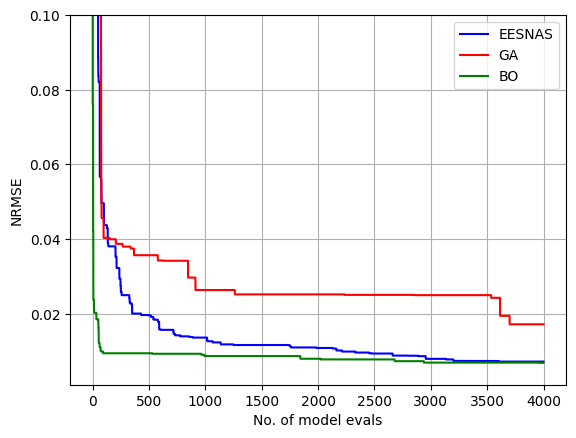

In [6]:
plotConvergences('mgs', "MGS NRMSE convergence", 0.1, 0.001)
plotConvergences('lorenz', "Lorenz NRMSE convergence", 0.05, 0)
plotConvergences('laser', "Santa fe laser NRMSE convergence", 5, 0.7)
plotConvergences('dde', "DDE NRMSE convergence", 0.25, 0.0004)
plotConvergences('sunspots', "Sunspots NRMSE convergence", 1.0, 0.465)
plotConvergences('water', "Water NRMSE convergence", 0.06, 0.04)